# Stock Price Prediction

In [1]:
# ============================
# Simplified paper replication
# Strategy-embedded loss + PBWA weighting
# Using free OHLCV from yfinance
# ============================

import os
import math
import random
import numpy as np
import pandas as pd

import yfinance as yf

import torch
import torch.nn as nn
from torch.optim import Adam


## 1. Experiment setup for Reproducibility

In [2]:
# ----------------------------
# Reproducibility
# ----------------------------
def set_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Data acquisition & ingestion (universe definition included)

In [3]:
# ----------------------------
# Universe: S&P500 tickers (free) -> Data acquisition and universe definition
# ----------------------------

def load_sp500_tickers_yf():
    t = yf.Ticker("^GSPC")
    tickers = list(t.constituents.keys()) if getattr(t, "constituents", None) else None
    if not tickers:
        raise RuntimeError("yfinance constituents not available in your version.")
    return [x.replace(".", "-") for x in tickers]

In [4]:
# ----------------------------
# Data download (OHLCV) -> data ingestion / raw data acquisition
# ----------------------------
def download_ohlcv(tickers, start="2010-01-01", end="2024-01-31", auto_adjust=False):
    """
    Returns: dict with keys Open, High, Low, Close, Volume as DataFrames [date x ticker]
    yfinance can be flaky; download in chunks.
    """
    if end is None:
        end = pd.Timestamp.today().strftime("%Y-%m-%d")

    chunks = []
    chunk_size = 100
    for i in range(0, len(tickers), chunk_size):
        chunks.append(tickers[i:i+chunk_size])

    frames = []
    for ch in chunks:
        data = yf.download(
            ch, start=start, end=end, auto_adjust=auto_adjust,
            group_by="column", threads=True, progress=False
        )
        # If multiple tickers, columns are MultiIndex: (field, ticker)
        if isinstance(data.columns, pd.MultiIndex):
            frames.append(data)
        else:
            # single ticker edge case
            data.columns = pd.MultiIndex.from_product([data.columns, ch])
            frames.append(data)

    data = pd.concat(frames, axis=1).sort_index()
    out = {}
    for field in ["Open", "High", "Low", "Close", "Volume"]:
        out[field] = data[field].copy()
    return out

In [5]:
# ----------------------------
# Main runner -> data prep / universe selection
# ----------------------------
def load_default_tickers_minimal():
    # A small, liquid starter set (expand as you like).
    tickers = [
        "AAPL","MSFT","AMZN","NVDA","GOOGL","META","BRK-B","JPM","XOM","UNH",
        "V","MA","LLY","AVGO","COST","PG","HD","ABBV","KO","PEP",
        "ADBE","CRM","WMT","CSCO","ACN","MCD","TMO","ABT","INTC","NFLX"
    ]
    return [t.replace(".", "-") for t in tickers]

## 3. Universe selection & preprocessing

In [6]:
# ----------------------------
# Liquidity filter (avg dollar volume) -> data preprocessing / universe selection
# ----------------------------
def make_universe_mask(
    data,
    tickers,
    top_n=21,
    short_w=60,        # short-term liquidity window
    long_w=252,        # long-term baseline for "becoming important"
    core_frac=0.70,    # 80% slots = absolute liquidity (stable tradability)
    min_dolv=1e6,      # minimum long-term $ volume to avoid microcap noise
    eps=1e-12,
):
    """
    Returns a boolean DataFrame mask[date, ticker] indicating whether ticker is in the tradable universe at date t.
    Causal at open: uses Close.shift(1) and Volume.shift(1) so universe at t only uses info up to t-1.

    Universe design:
      - CORE bucket: top core_n by trailing (short_w) dollar volume
      - GROWTH bucket: top growth_n by liquidity acceleration (log(dolv_short) - log(dolv_long)),
        but only if dolv_long >= min_dolv (to avoid tiny illiquid names).
    """
    close = data["Close"][tickers].shift(1)
    volu  = data["Volume"][tickers].shift(1)
    dolv1 = close * volu  # daily $ volume (lagged)

    dolv_short = dolv1.rolling(short_w, min_periods=short_w).mean()

    core_n = max(1, int(round(top_n * core_frac)))
    growth_n = max(0, top_n - core_n)

    # CORE: strongest absolute liquidity
    core_rank = dolv_short.rank(axis=1, ascending=False, method="first")
    core_mask = core_rank.le(core_n)

    if growth_n > 0:
        dolv_long = dolv1.rolling(long_w, min_periods=long_w).mean()
        # "becoming important": liquidity acceleration vs its own history
        growth_score = (np.log(dolv_short + eps) - np.log(dolv_long + eps))

        # guardrail: only consider names that are at least somewhat tradable long-term
        eligible = dolv_long.ge(min_dolv)

        growth_rank = growth_score.where(eligible).rank(axis=1, ascending=False, method="first")
        growth_mask = growth_rank.le(growth_n)
    else:
        growth_mask = core_mask & False  # all False, same shape

    mask = (core_mask | growth_mask).fillna(False)
    return mask


# ----------------------------
# Liquidity filter v2 (buffered / threshold) -> universe selection
# ----------------------------
def make_universe_mask_v2(
    data,
    tickers,
    target_n=21,
    short_w=60,
    min_dolv_short=5e6,      # minimum trailing $ volume (lagged)
    buffer_mult=1.5,         # allow more than target_n names (captures "missed" opportunities)
    cap_max_names=None,      # hard cap if you want
    eps=1e-12,
):
    """
    A more permissive liquidity universe that avoids over-pruning when len(tickers) >> target_n.

    Idea:
      - Compute trailing short_w avg dollar volume (lagged).
      - Keep ALL names above a minimum $-volume threshold (min_dolv_short),
        but also (optionally) cap the daily universe to a buffered top-K by liquidity:
          K = ceil(buffer_mult * target_n)
      - This keeps tradability, while giving the model a bigger opportunity set than a strict top-N.

    Returns mask[date, ticker] (bool).
    """
    target_n = int(max(1, target_n))
    close = data["Close"][tickers].shift(1)
    volu  = data["Volume"][tickers].shift(1)
    dolv1 = close * volu

    dolv_short = dolv1.rolling(short_w, min_periods=short_w).mean()

    eligible = dolv_short.ge(min_dolv_short)

    # Buffered cap by liquidity rank (optional)
    K = int(np.ceil(buffer_mult * target_n))
    if cap_max_names is not None:
        K = int(min(K, cap_max_names))

    if K is not None and K > 0:
        rank = dolv_short.rank(axis=1, ascending=False, method="first")
        topk = rank.le(K)
        mask = (eligible & topk).fillna(False)
    else:
        mask = eligible.fillna(False)

    return mask


## 4. Feature engineering & label construction

In [7]:
# ----------------------------
# Features (all shifted by 1 day) -> feature engineering / technical indicators
# ----------------------------
def rsi(close: pd.DataFrame, window: int = 14):
    delta = close.diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    roll_up = up.rolling(window, min_periods=window).mean()
    roll_down = down.rolling(window, min_periods=window).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

In [8]:
def make_features(data): # -> feature engineering + label construction
    """
    data: dict Open/Close/Volume DF
    returns: features panel (date x ticker x feature), labels (date x ticker)
    """
    close = data["Close"]
    open_ = data["Open"]
    volu = data["Volume"]

    # Label: open->close return for day t (what we trade)
    y = (close / open_) - 1.0

    # Basic returns for feature engineering (close-to-close)
    cc = close.pct_change()

    # Momentum / reversal
    mom20 = close / close.shift(20) - 1
    mom60 = close / close.shift(60) - 1
    mom252 = close / close.shift(252) - 1
    rev5 = close / close.shift(5) - 1

    # Volatility
    vol20 = cc.rolling(20, min_periods=20).std(ddof=0)

    # MA ratios
    ma20 = close.rolling(20, min_periods=20).mean()
    ma60 = close.rolling(60, min_periods=60).mean()
    prc_ma20 = close / (ma20 + 1e-12) - 1
    prc_ma60 = close / (ma60 + 1e-12) - 1

    # Volume z-score
    vma20 = volu.rolling(20, min_periods=20).mean()
    vsd20 = volu.rolling(20, min_periods=20).std(ddof=0)
    volz20 = (volu - vma20) / (vsd20 + 1e-12)

    # RSI
    rsi14 = rsi(close, 14) / 100.0  # scale to [0,1]

    feats = {
        "mom20": mom20,
        "mom60": mom60,
        "mom252": mom252,
        "rev5": rev5,
        "vol20": vol20,
        "prc_ma20": prc_ma20,
        "prc_ma60": prc_ma60,
        "volz20": volz20,
        "rsi14": rsi14,
    }

    # Shift ALL features by 1 day to ensure they're known at time of trading (today open)
    feats = {k: v.shift(1) for k, v in feats.items()}

    return feats, y

## 5. Dataset preparation & batching

In [9]:
# ----------------------------
# Build day-batches of sequences -> data preparation / batching,
# ----------------------------
def build_day_batches(feats_dict, y, tickers, seq_len=20, start_date=None, end_date=None, universe_mask=None, min_names=20):


    """
    For each date t, we create X: [n_stocks, seq_len, n_features], Y: [n_stocks]
    Sequences are constructed from shifted features, so they end at t (feature at t uses info up to t-1).
    """
    feat_names = list(feats_dict.keys())
    dates = y.index

    if start_date is not None:
        dates = dates[dates >= pd.to_datetime(start_date)]
    if end_date is not None:
        dates = dates[dates <= pd.to_datetime(end_date)]

    # Stack features into (date x ticker x feat)
    # We'll keep in pandas for alignment then convert per day.
    F = []
    for fn in feat_names:
        df = feats_dict[fn][tickers]
        F.append(df)
    # shape: list of DFs
    # We'll fetch rolling windows per ticker per day.
    # Efficient enough for ~200 tickers, ~3000 days.

    batches = []
    for t in dates:
        # Need seq_len rows ending at t
        idx_pos = y.index.get_loc(t)
        if idx_pos < seq_len:
            continue
        window_dates = y.index[idx_pos - seq_len + 1 : idx_pos + 1]

        # Build X for all tickers: [n, seq_len, f]
        X_list = []
        for fn in feat_names:
            X_list.append(feats_dict[fn].loc[window_dates, tickers].values[:, :])
        X = np.stack(X_list, axis=-1)  # [seq_len, n, f]
        X = np.transpose(X, (1, 0, 2)) # [n, seq_len, f]

        Y = y.loc[t, tickers].values  # [n]

        # Drop tickers with any NaNs in sequence or label
        # Drop tickers with any NaNs in sequence or label
        mask = np.isfinite(Y)
        mask &= np.isfinite(X).all(axis=(1, 2))

        # NEW: apply dynamic universe membership at date t
        if universe_mask is not None:
            um = universe_mask.loc[t, tickers].values
            um = np.asarray(um, dtype=bool)
            mask &= um

        if mask.sum() < min_names:
            continue

        # inside build_day_batches, right before append
        tks_masked = list(np.array(tickers)[mask])
        batches.append((t, X[mask], Y[mask], tks_masked))


    return batches, feat_names

## 6. Model architecture

In [10]:
# ----------------------------
# Model: LSTM -> scalar return -> model architecture
# ----------------------------
class LSTMAlpha(nn.Module):
    def __init__(self, n_features, hidden=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        # x: [batch=n_stocks, seq_len, n_features]
        out, _ = self.lstm(x)
        last = out[:, -1, :]          # last step
        pred = self.head(last).squeeze(-1)
        return pred

## 7. Training 

In [11]:
# ----------------------------
# Train (one day = one batch)
# Strategy-embedded objective -> training
# ----------------------------
def train_model(
    batches_train,
    batches_val,
    n_features,
    lam=0.5,                # strategy weight
    k_turn=0.1,             # turnover penalty weight
    k_conc=0.1,             # concentration penalty weight
    gamma=0.0,
    max_w=0.02,
    lr=1e-3,
    epochs=5,
    # NEW: choose long-only vs long-short for the embedded strategy term
    weight_mode="long",     # "long" or "long_short"
    gross_long=1.0,         # only used for long_short
    gross_short=1.0,        # only used for long_short
):
    """
    Trains LSTMAlpha using an objective:
        loss = MSE - lam * PnL + k_turn * turnover + k_conc * concentration

    IMPORTANT:
    - If weight_mode="long": PnL uses pbwa_weights (long-only).
    - If weight_mode="long_short": PnL uses pbwa_long_short_weights (long-short).
    """
    model = LSTMAlpha(n_features=n_features, hidden=64).to(DEVICE)
    opt = Adam(model.parameters(), lr=lr)

    best_val = -np.inf
    best_state = None

    def _weights_from_pred(pred):
        if weight_mode == "long_short":
            return pbwa_long_short_weights(
                pred,
                gamma=gamma,
                max_abs_w=max_w,
                gross_long=gross_long,
                gross_short=gross_short,
            )
        else:
            return pbwa_weights(pred, gamma=gamma, max_w=max_w)

    for ep in range(1, epochs + 1):
        model.train()
        prev_w = None
        tr_pnl = []
        tr_mse = []

        for (dt, X_np, Y_np, _tks) in batches_train:
            X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
            Y = torch.tensor(Y_np, dtype=torch.float32, device=DEVICE)

            pred = model(X)
            mse = torch.mean((pred - Y) ** 2)

            w = _weights_from_pred(pred)
            pnl = torch.sum(w * Y)  # realized portfolio return for that day (gross)

            # penalties
            conc = torch.sum(w ** 2)  # higher = more concentrated
            if prev_w is None:
                turn = torch.tensor(0.0, device=DEVICE)
            else:
                # turnover across consecutive training days (approx)
                # Note: sizes can differ due to NaN masking; we skip turnover in that case.
                if prev_w.shape == w.shape:
                    turn = torch.sum(torch.abs(w - prev_w))
                else:
                    turn = torch.tensor(0.0, device=DEVICE)

            loss = mse - lam * pnl + k_turn * turn + k_conc * conc

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()

            prev_w = w.detach()

            tr_pnl.append(float(pnl.detach().cpu().item()))
            tr_mse.append(float(mse.detach().cpu().item()))

        # Validation: measure average realized pnl (gross) and MSE
        model.eval()
        with torch.no_grad():
            val_pnl = []
            val_mse = []
            for (dt, X_np, Y_np, _tks) in batches_val:
                X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
                Y = torch.tensor(Y_np, dtype=torch.float32, device=DEVICE)
                pred = model(X)

                mse = torch.mean((pred - Y) ** 2)

                w = _weights_from_pred(pred)
                pnl = torch.sum(w * Y)

                val_pnl.append(float(pnl.cpu().item()))
                val_mse.append(float(mse.cpu().item()))

        val_score = np.mean(val_pnl)  # goal-aligned
        if val_score > best_val:
            best_val = val_score
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {ep:02d} | train pnl {np.mean(tr_pnl):+.6f} | train mse {np.mean(tr_mse):.6f} "
            f"| val pnl {np.mean(val_pnl):+.6f} | val mse {np.mean(val_mse):.6f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

## 8. Trading strategy & execution (portfolio construction + rules)

In [12]:
# ----------------------------
# PBWA weights (PyTorch) -> portfolio construction / execution logic
# ----------------------------
def pbwa_weights(pred, gamma=0.0, max_w=0.02, eps=1e-12):
    """
    pred: [n]
    returns weights [n], long-only.
    """
    raw = torch.relu(pred - gamma)
    s = raw.sum()
    if s.item() <= eps:
        # fallback: no signal -> all zeros (cash)
        return torch.zeros_like(raw)

    w = raw / (s + eps)

    # hard cap + renorm (subgrad ok)
    w = torch.clamp(w, max=max_w)
    if w.sum().item() <= eps:
        return torch.zeros_like(w)
    w = w / (w.sum() + eps)
    return w

In [13]:
# ----------------------------
# Long-short extension of PBWA + trade counting utilities -> portfolio construction / trading rule
# ----------------------------
def pbwa_long_short_weights(
    pred,
    gamma=0.0,
    max_abs_w=0.02,
    gross_long=1.0,
    gross_short=1.0,
    eps=1e-12,
):
    """
    Long-short analogue of PBWA.

    - Long scores:  ReLU(pred - gamma)
    - Short scores: ReLU(-pred - gamma)
    - Normalize longs to sum to gross_long
    - Normalize shorts (absolute) to sum to gross_short
    - Cap per-name absolute weight to max_abs_w (applied separately to long and short sides)
    """

    raw_long  = torch.relu(pred - gamma)
    raw_short = torch.relu(-pred - gamma)

    w_long = torch.zeros_like(pred)
    w_short = torch.zeros_like(pred)

    sL = raw_long.sum()
    sS = raw_short.sum()

    if sL.item() > eps:
        w_long = gross_long * (raw_long / (sL + eps))
    if sS.item() > eps:
        w_short = gross_short * (raw_short / (sS + eps))

    w = w_long - w_short

    # Apply per-name cap (separately) then renormalize each side to maintain gross exposures
    pos = torch.clamp(w, min=0.0)
    neg = torch.clamp(-w, min=0.0)  # magnitudes

    pos = torch.clamp(pos, max=max_abs_w)
    neg = torch.clamp(neg, max=max_abs_w)

    pos_sum = pos.sum()
    neg_sum = neg.sum()

    if pos_sum.item() > eps:
        pos = gross_long * (pos / (pos_sum + eps))
    else:
        pos = torch.zeros_like(pos)

    if neg_sum.item() > eps:
        neg = gross_short * (neg / (neg_sum + eps))
    else:
        neg = torch.zeros_like(neg)

    return pos - neg

## 9. Backtesting & analytics

In [14]:
def trade_action_counts(w, prev_w=None, tol=1e-8): # -> evaluation/backtesting analytics
    """
    Counts how many names increased/decreased weight vs previous day.

    Interpretation:
      - dw > 0  => "buy" (increase long OR cover short)
      - dw < 0  => "sell" (reduce long OR increase short)

    Returns:
      buys_n, sells_n, buy_notional, sell_notional, n_long, n_short
    """
    n_long = int((w > tol).sum().item())
    n_short = int((w < -tol).sum().item())

    if prev_w is None or prev_w.shape != w.shape:
        return 0, 0, 0.0, 0.0, n_long, n_short

    dw = w - prev_w
    buys_mask = dw > tol
    sells_mask = dw < -tol

    buys_n = int(buys_mask.sum().item())
    sells_n = int(sells_mask.sum().item())

    buy_notional = float(dw[buys_mask].sum().item()) if buys_n else 0.0
    sell_notional = float((-dw[sells_mask]).sum().item()) if sells_n else 0.0

    return buys_n, sells_n, buy_notional, sell_notional, n_long, n_short

In [15]:
# ----------------------------
# Backtest on batches (with costs) -> evaluation/backtesting
# ----------------------------
def backtest_batches(
    model,
    batches,
    tc_bps_per_side=10.0,
    slip_bps=5.0,
    gamma=0.0,
    max_w=0.02,
    weight_mode="long",      # "long" or "long_short"
    gross_long=1.0,          # only used for long_short
    gross_short=1.0,         # only used for long_short
    weight_fn=None,          # optional custom weighting function: w = weight_fn(pred)
    tol=1e-8,
    # NEW: rebalance logic (weekly + exceptions)
    rebalance_rule="D",      # "D" (daily) or e.g. "W-MON", "W-FRI"
    shock_consecutive_down=0,# 0 disables; if >0, triggers an off-cycle rebalance after N down days
    shock_proxy_rets=None,   # optional pd.Series (date->proxy return), e.g. SPY open->close
    # NEW: smoother for predictions (avoid acting on pure t-1 noise)
    pred_smooth_span=None,   # int span for EMA; None disables
):
    """
    Backtest one-day batches.

    Execution model:
      - We trade at open and earn open->close returns (Y), consistent with make_features().

    Rebalance:
      - If rebalance_rule == "D": recompute weights every day.
      - If rebalance_rule == "W-MON"/"W-FRI": recompute weights only on that weekday; hold weights otherwise.
      - Optional "shock" exception: if the proxy return is negative for shock_consecutive_down days in a row,
        we force a rebalance on that day (even if not scheduled).

    Holdings:
      - Saves BOTH long and short holdings (signed weights) with a "side" column.
    """
    model.eval()
    cost_rate = (tc_bps_per_side + slip_bps) * 1e-4  # bps -> fraction

    # --- safety: ensure inputs are torch tensors on the same device/dtype as the model
    try:
        _p0 = next(model.parameters())
        _model_device = _p0.device
        _model_dtype = _p0.dtype
    except StopIteration:
        _model_device = torch.device("cpu")
        _model_dtype = torch.float32

    # --- helpers
    def _parse_rebalance_rule(rule):
        rule = str(rule).upper().strip()
        if rule in ("D","DAILY"):
            return ("D", None)
        if rule.startswith("W-"):
            wd = rule.split("-",1)[1]
            map_wd = {"MON":0,"TUE":1,"WED":2,"THU":3,"FRI":4,"SAT":5,"SUN":6}
            if wd not in map_wd:
                raise ValueError(f"Unknown weekly weekday in rebalance_rule={rule}")
            return ("W", map_wd[wd])
        if rule in ("W","WEEKLY"):
            return ("W", 0)  # default Monday
        raise ValueError(f"Unsupported rebalance_rule={rule}. Use 'D' or 'W-MON'/'W-FRI' etc.")

    freq_kind, weekly_wd = _parse_rebalance_rule(rebalance_rule)

    def _is_rebalance_date(dt):
        if freq_kind == "D":
            return True
        # weekly
        return pd.to_datetime(dt).weekday() == weekly_wd

    def _turnover_L1(w_map, prev_map):
        if prev_map is None:
            return 0.0
        keys = set(w_map.keys()) | set(prev_map.keys())
        return float(sum(abs(w_map.get(k,0.0) - prev_map.get(k,0.0)) for k in keys))

    def _action_counts(w_map, prev_map):
        # Uses aligned union of tickers so changing universe still counts
        keys = set(w_map.keys()) | (set(prev_map.keys()) if prev_map else set())
        if not keys:
            return 0,0,0.0,0.0,0,0

        buys_n = sells_n = 0
        buy_not = sell_not = 0.0
        for k in keys:
            dw = w_map.get(k,0.0) - (prev_map.get(k,0.0) if prev_map else 0.0)
            if dw > tol:
                buys_n += 1
                buy_not += dw
            elif dw < -tol:
                sells_n += 1
                sell_not += -dw
        n_long = sum(1 for v in w_map.values() if v > tol)
        n_short = sum(1 for v in w_map.values() if v < -tol)
        return buys_n, sells_n, float(buy_not), float(sell_not), int(n_long), int(n_short)

    # --- state
    records = []                 # stock-level holdings (long + short)
    dates = []
    gross = []
    net = []
    turnover = []

    buys_cnt = []
    sells_cnt = []
    buy_notional = []
    sell_notional = []
    n_long_list = []
    n_short_list = []
    rebalance_flag = []

    prev_w_map = None            # executed weights from previous day (dict)
    target_w_map = None          # last rebalanced target weights (dict)
    ema_pred = {}                # ticker -> smoothed pred
    consec_down = 0

    # EMA alpha (if enabled)
    if pred_smooth_span is not None:
        span = int(max(1, pred_smooth_span))
        alpha = 2.0 / (span + 1.0)
    else:
        alpha = None

    # normalize proxy returns index for fast lookups
    proxy = None
    if shock_proxy_rets is not None:
        proxy = shock_proxy_rets.copy()
        proxy.index = pd.to_datetime(proxy.index)

    with torch.no_grad():
        for (dt, X, Y, tks) in batches:
            dt = pd.to_datetime(dt)

            # --- ensure X,Y are torch tensors (model expects torch inputs)
            if not torch.is_tensor(X):
                X = torch.tensor(X, dtype=_model_dtype, device=_model_device)
            else:
                X = X.to(device=_model_device, dtype=_model_dtype)
            if not torch.is_tensor(Y):
                Y = torch.tensor(Y, dtype=_model_dtype, device=_model_device)
            else:
                Y = Y.to(device=_model_device, dtype=_model_dtype)

            # --- proxy down-streak tracking
            if shock_consecutive_down and shock_consecutive_down > 0:
                if proxy is not None and dt in proxy.index:
                    px = float(proxy.loc[dt])
                else:
                    # fallback proxy: equal-weight "market" of today's active names
                    px = float(Y.detach().cpu().mean().item())
                consec_down = (consec_down + 1) if (px < 0.0) else 0
            else:
                consec_down = 0

            scheduled = _is_rebalance_date(dt)
            triggered = (shock_consecutive_down and consec_down >= int(shock_consecutive_down))
            do_rebalance = (target_w_map is None) or scheduled or triggered            # --- always compute preds (lets us smooth, even on hold-days)
            pred = model(X)  # [n]
            pred_np = pred.detach().cpu().numpy()
            raw_map = dict(zip(tks, pred_np))
            y_np = Y.detach().cpu().numpy()

            # smooth prediction per ticker (EMA)
            if alpha is not None:
                for tk, pi in zip(tks, pred_np):
                    prev = ema_pred.get(tk, pi)
                    ema_pred[tk] = alpha * float(pi) + (1.0 - alpha) * float(prev)
                signal_np = np.array([ema_pred.get(tk, float(pi)) for tk, pi in zip(tks, pred_np)], dtype=float)
            else:
                signal_np = pred_np.astype(float)

            # --- choose weights
            if do_rebalance:
                sig = torch.tensor(signal_np, dtype=pred.dtype, device=pred.device)

                if weight_fn is not None:
                    w = weight_fn(sig)
                else:
                    if weight_mode == "long_short":
                        w = pbwa_long_short_weights(
                            sig,
                            gamma=gamma,
                            max_abs_w=max_w,
                            gross_long=gross_long,
                            gross_short=gross_short,
                        )
                    else:
                        w = pbwa_weights(sig, gamma=gamma, max_w=max_w)

                w_np = w.detach().cpu().numpy()
                target_w_map = dict(zip(tks, w_np))
                rebalance_flag.append(1)
            else:
                # hold last target weights, apply to today's active tickers only (missing -> cash)
                w_np = np.array([target_w_map.get(tk, 0.0) for tk in tks], dtype=float)
                rebalance_flag.append(0)

            w_map = dict(zip(tks, w_np))

            # --- returns + costs
            g = float(np.sum(w_np * y_np))

            to = _turnover_L1(w_map, prev_w_map)
            c = cost_rate * to
            n = g - c

            # --- store holdings (long + short)
            for tk, wi, pi, ri in zip(tks, w_np, signal_np, y_np):
                if abs(wi) > tol:
                    records.append({
                        "date": dt,
                        "ticker": tk,
                        "weight": float(wi),              # signed
                        "abs_weight": float(abs(wi)),
                        "side": "long" if wi > 0 else "short",
                        "pred_used": float(pi),           # signal used for sizing (smoothed if enabled)
                        "pred_raw": float(raw_map.get(tk, np.nan)),
                        "ret": float(ri),
                        "rebalanced": int(do_rebalance),
                    })

            b_n, s_n, b_not, s_not, nL, nS = _action_counts(w_map, prev_w_map)

            dates.append(dt)
            gross.append(g)
            net.append(n)
            turnover.append(to)

            buys_cnt.append(b_n)
            sells_cnt.append(s_n)
            buy_notional.append(b_not)
            sell_notional.append(s_not)
            n_long_list.append(nL)
            n_short_list.append(nS)

            prev_w_map = w_map.copy()

    idx = pd.to_datetime(dates)
    sr = pd.Series(net, index=idx).sort_index()
    gr = pd.Series(gross, index=idx).sort_index()
    to = pd.Series(turnover, index=idx).sort_index()
    eq = (1 + sr.fillna(0)).cumprod()

    holdings = pd.DataFrame(records).sort_values(["date","abs_weight"], ascending=[True, False])
    return {
        "net": sr,
        "gross": gr,
        "equity": eq,
        "turnover": to,
        "holdings": holdings,
        "buys_count": pd.Series(buys_cnt, index=idx).sort_index(),
        "sells_count": pd.Series(sells_cnt, index=idx).sort_index(),
        "buy_notional": pd.Series(buy_notional, index=idx).sort_index(),
        "sell_notional": pd.Series(sell_notional, index=idx).sort_index(),
        "n_long": pd.Series(n_long_list, index=idx).sort_index(),
        "n_short": pd.Series(n_short_list, index=idx).sort_index(),
        "rebalanced": pd.Series(rebalance_flag, index=idx).sort_index(),
    }

## 10. Evaluation reporting & debugging

In [16]:
def trades_on_date(bt_out, date): # -> evaluation / reporting / debugging
    """Convenience: inspect buy/sell counts for a specific date."""
    d = pd.to_datetime(date)
    return {
        "buys_count": float(bt_out["buys_count"].loc[d]),
        "sells_count": float(bt_out["sells_count"].loc[d]),
        "buy_notional": float(bt_out["buy_notional"].loc[d]),
        "sell_notional": float(bt_out["sell_notional"].loc[d]),
        "n_long": float(bt_out["n_long"].loc[d]),
        "n_short": float(bt_out["n_short"].loc[d]),
    }

In [17]:
def average_trades(bt_out): #-> evaluation / reporting
    """Convenience: average buy/sell counts over the backtest period."""
    return {
        "avg_buys_per_day": float(bt_out["buys_count"].mean()),
        "avg_sells_per_day": float(bt_out["sells_count"].mean()),
        "avg_buy_notional_per_day": float(bt_out["buy_notional"].mean()),
        "avg_sell_notional_per_day": float(bt_out["sell_notional"].mean()),
        "avg_n_long_positions": float(bt_out["n_long"].mean()),
        "avg_n_short_positions": float(bt_out["n_short"].mean()),
    }

In [18]:
def perf_summary(daily_rets, freq=252): # -> evaluation/reporting
    r = daily_rets.dropna()
    if len(r) < 10:
        return {}
    mu = r.mean()
    sd = r.std(ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)
    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    mdd = dd.min()
    cagr = eq.iloc[-1] ** (freq / len(r)) - 1
    return {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "AvgDailyTurnover": float(np.mean(np.abs(r*0 + 1)))  # placeholder, fill separately if desired
    }

In [19]:
def perf_block(rets, freq=252): # -> evaluation/reporting
    r = rets.dropna()
    ev = r.mean()
    vv = r.var(ddof=0)
    sharpe = (ev / (r.std(ddof=0) + 1e-12)) * np.sqrt(freq)
    eq = (1+r).cumprod()
    mdd = (eq/eq.cummax()-1).min()
    cagr = eq.iloc[-1]**(freq/len(r)) - 1
    return {"E_daily": float(ev), "V_daily": float(vv), "Sharpe": float(sharpe), "CAGR": float(cagr), "MaxDD": float(mdd)}


## 11. Performance & risk attribution

In [20]:
def alpha_beta(strat_rets, mkt_rets): #-> evaluation / performance attribution
    x = mkt_rets.align(strat_rets, join="inner")[0].values
    y = strat_rets.align(mkt_rets, join="inner")[0].values
    X = np.column_stack([np.ones_like(x), x])
    # OLS
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    alpha, beta = b[0], b[1]
    # t-stat alpha
    resid = y - X @ b
    s2 = (resid @ resid) / (len(y) - 2)
    var_b = s2 * np.linalg.inv(X.T @ X)
    se_alpha = np.sqrt(var_b[0,0])
    t_alpha = alpha / (se_alpha + 1e-12)
    return alpha, beta, t_alpha


In [21]:
def rolling_alpha_beta(strat, mkt, window=252): # -> evaluation / risk attribution
    df = pd.concat([strat, mkt], axis=1, join="inner")
    df.columns = ["s", "m"]
    alphas, betas = [], []
    idx = []

    for i in range(window, len(df)+1):
        sub = df.iloc[i-window:i]
        x = sub["m"].values
        y = sub["s"].values
        X = np.column_stack([np.ones_like(x), x])
        b = np.linalg.lstsq(X, y, rcond=None)[0]
        alpha, beta = b[0], b[1]
        idx.append(sub.index[-1])
        alphas.append(alpha * 252)   # annualize
        betas.append(beta)

    return pd.Series(alphas, index=idx, name="alpha_rolling_yr"), pd.Series(betas, index=idx, name="beta_rolling")

## 12. Experiment Driver

In [22]:
def run_experiment(
    start="2010-01-01",
    end="2024-12-31",
    top_n=21,
    seq_len=20,
    train_end="2017-12-31",
    val_end="2019-12-31",
    gamma=0.0,
    max_w=0.02,
    tc_bps=10.0,
    slip_bps=5.0,
    epochs=6,
    lr=1e-3,
    lam_embedded=0.8,
    tickers=None,
    # NEW: long-short controls
    weight_mode="long",     # "long" or "long_short"
    gross_long=1.0,
    gross_short=1.0,
    # NEW: universe selection controls
    universe_mode="strict_top_n",     # "strict_top_n" (old) or "buffered_v2"
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
    # NEW: execution controls (weekly + exceptions + smoothing)
    rebalance_rule="D",               # "D" or "W-MON"/"W-FRI"
    shock_consecutive_down=0,         # 0 disables; try 3 for "3 down days"
    pred_smooth_span=None,            # e.g. 5 or 10; None disables
):
    """
    Runs the full pipeline:
    - download data
    - build features + day-batches
    - train baseline (MSE) and embedded (MSE - lam*PnL + penalties)
    - backtest both

    universe_mode:
      - "strict_top_n": original dynamic top-N liquidity universe (core + growth bucket).
      - "buffered_v2": keep a buffered top-K by liquidity AND a $-volume threshold (less pruning).

    rebalance_rule:
      - "D": daily rebalance (original).
      - "W-MON"/"W-FRI": weekly rebalance; holds weights on other days.

    shock_consecutive_down:
      - if >0, forces an off-cycle rebalance after N consecutive down days in the proxy (SPY).
    """
    if tickers is None:
        print("No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)")
        tickers = load_default_tickers_minimal()

    bench = "SPY"
    all_tickers = list(dict.fromkeys(tickers + [bench]))  # preserve order, remove dupes

    data = download_ohlcv(all_tickers, start=start, end=end, auto_adjust=False)

    # --- Universe selection (NO leakage): dynamic + causal
    base_univ = tickers

    top_n = int(top_n)
    top_n = max(1, min(top_n, len(base_univ)))
    min_names = max(2, int(np.ceil(0.6 * top_n)))   # 60% of top_n, minimum 2

    if len(base_univ) > top_n:
        if str(universe_mode).lower() in ("buffered_v2","v2","buffered","threshold"):
            universe_mask = make_universe_mask_v2(
                data,
                base_univ,
                target_n=top_n,
                short_w=60,
                min_dolv_short=universe_min_dolv_short,
                buffer_mult=universe_buffer_mult,
            )
        else:
            universe_mask = make_universe_mask(
                data,
                base_univ,
                top_n=top_n,
                short_w=60,
                long_w=252,
                core_frac=0.70,
                min_dolv=1e6,
            )
    else:
        universe_mask = pd.DataFrame(True, index=data["Close"].index, columns=base_univ)

    feats, y = make_features(data)

    # IMPORTANT: pass tickers=base_univ (not prefiltered) + universe_mask for per-day selection
    batches_all, feat_names = build_day_batches(
        feats, y,
        tickers=base_univ,
        seq_len=seq_len,
        universe_mask=universe_mask,
        min_names=min_names
    )

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    print(f"Train days: {len(batches_train)}, Val days: {len(batches_val)}, Test days: {len(batches_test)}")
    print(f"Features: {feat_names}")
    avg_names = np.mean([len(b[3]) for b in batches_all]) if len(batches_all) else 0.0
    print(f"Avg active universe size per day: {avg_names:.1f} | target top_n={top_n} | universe_mode={universe_mode}")

    print(f"Weight mode: {weight_mode} | gross_long={gross_long}, gross_short={gross_short}")
    print(f"Execution: rebalance_rule={rebalance_rule}, shock_consecutive_down={shock_consecutive_down}, pred_smooth_span={pred_smooth_span}")

    n_features = len(feat_names)

    print("\n=== Train baseline (MSE only) ===")
    model_base = train_model(
        batches_train, batches_val, n_features,
        lam=0.0, k_turn=0.0, k_conc=0.0,
        gamma=gamma, max_w=max_w,
        lr=lr, epochs=epochs,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
    )

    print("\n=== Train strategy-embedded ===")
    model_emb = train_model(
        batches_train, batches_val, n_features,
        lam=lam_embedded, k_turn=0.05, k_conc=0.05,
        gamma=gamma, max_w=max_w,
        lr=lr, epochs=epochs,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
    )

    # ----------------------------
    # Expose last trained artifacts (so we can save/freeze and re-use the final model)
    # ----------------------------
    global LAST_MODEL_BASE, LAST_MODEL_EMB, LAST_RUN_DATA, LAST_RUN_UNIVERSE, LAST_FEAT_NAMES, LAST_RUN_CFG
    LAST_MODEL_BASE = model_base
    LAST_MODEL_EMB  = model_emb
    LAST_RUN_DATA   = data
    LAST_RUN_UNIVERSE = base_univ
    LAST_FEAT_NAMES = feat_names
    LAST_RUN_CFG = dict(
        seq_len=seq_len,
        gamma=gamma,
        max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        tc_bps=tc_bps,
        slip_bps=slip_bps,
        universe_mode=universe_mode,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        pred_smooth_span=pred_smooth_span,
    )

    # Proxy for shocks: SPY open->close (matches y label); pass full series, backtest looks up by date
    spy_rets_full = (data["Close"][["SPY"]] / data["Open"][["SPY"]] - 1.0)["SPY"]

    bt_base = backtest_batches(
        model_base, batches_test,
        tc_bps_per_side=tc_bps, slip_bps=slip_bps,
        gamma=gamma, max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        shock_proxy_rets=spy_rets_full,
        pred_smooth_span=pred_smooth_span,
    )

    bt_emb = backtest_batches(
        model_emb, batches_test,
        tc_bps_per_side=tc_bps, slip_bps=slip_bps,
        gamma=gamma, max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        shock_proxy_rets=spy_rets_full,
        pred_smooth_span=pred_smooth_span,
    )

    spy = spy_rets_full.reindex(bt_base["net"].index).dropna()
    spy_eq = (1 + spy).cumprod()

    return {
        "baseline": bt_base,
        "embedded": bt_emb,
        "spy_rets": spy,
        "spy_eq": spy_eq,
        "feat_names": feat_names,
        "universe": base_univ,
        "weight_mode": weight_mode,
        "gross_long": gross_long,
        "gross_short": gross_short,
        "universe_mode": universe_mode,
        "rebalance_rule": rebalance_rule,
        "shock_consecutive_down": shock_consecutive_down,
        "pred_smooth_span": pred_smooth_span,
    }


## 13. Testing zone (plots, observation of the perfomance of the model)

In [24]:
# Example: long-short, buffered universe, weekly rebalance with shock exceptions + mild smoothing
out_ls = run_experiment(
    top_n=20,
    lam_embedded=0.8,
    weight_mode="long_short",
    gross_long=1.0,
    gross_short=1.0,
    universe_mode="buffered_v2",
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
    rebalance_rule="W-FRI",
    shock_consecutive_down=3,
    pred_smooth_span=5,
)

print("Baseline final equity:", out_ls["baseline"]["equity"].iloc[-1])
print("Embedded final equity:", out_ls["embedded"]["equity"].iloc[-1])


No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=20 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=3, pred_smooth_span=5

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000160 | train mse 0.001235 | val pnl +0.000337 | val mse 0.000597
Epoch 02 | train pnl +0.000222 | train mse 0.000326 | val pnl -0.000068 | val mse 0.000340
Epoch 03 | train pnl -0.000007 | train mse 0.000263 | val pnl +0.000481 | val mse 0.000219
Epoch 04 | train pnl -0.000290 | train mse 0.000234 | val pnl +0.000234 | val mse 0.000249
Epoch 05 | train pnl +0.000047 | train mse 0.000214 | val pnl +0.000391 | val mse 0.000216
Epoch 06 | train pnl +0.000266 | train ms

In [25]:
print("Baseline final equity:", out_ls["baseline"]["equity"].iloc[-1])
print("Baseline final equity:", out_ls["embedded"]["equity"].iloc[-1])
print("Embedded final gross:", out_ls["embedded"]["gross"].iloc[-1])


Baseline final equity: 0.7018494663824287
Baseline final equity: 1.6878744991299843
Embedded final gross: -0.0009735488958124692


In [26]:
print("Avg turnover baseline:", out_ls["baseline"]["turnover"].mean())
print("Avg turnover embedded:", out_ls["embedded"]["turnover"].mean())

# If you stored weights: out["baseline"]["weights"] etc. If not, approximate cash as near-zero returns:
cash_like_embedded = (out_ls["embedded"]["gross"].abs() < 1e-8).mean()
print("Embedded ~cash days (gross≈0):", cash_like_embedded)


Avg turnover baseline: 0.41558599948002345
Avg turnover embedded: 0.004110973144236096
Embedded ~cash days (gross≈0): 0.0


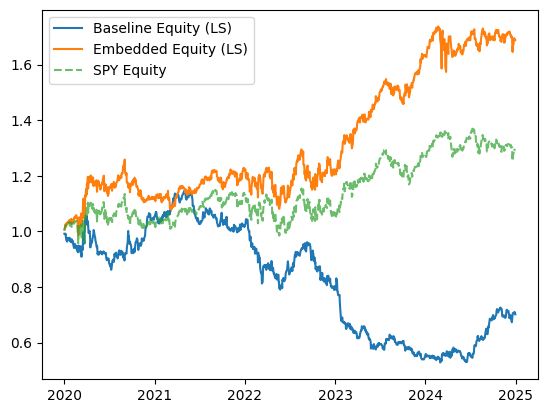

In [27]:
import matplotlib.pyplot as plt
plt.plot(out_ls["baseline"]["equity"], label="Baseline Equity (LS)")
plt.plot(out_ls["embedded"]["equity"], label="Embedded Equity (LS)")
plt.plot(out_ls["spy_eq"], label="SPY Equity", linestyle="--", alpha=0.7)
plt.legend()
plt.show()


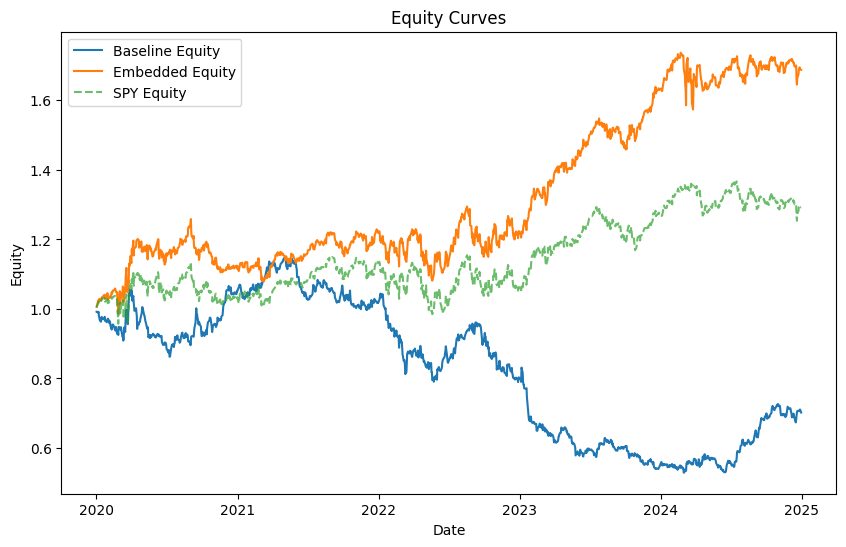

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["equity"], label="Baseline Equity")
plt.plot(out_ls["embedded"]["equity"], label="Embedded Equity")
plt.plot(out_ls["spy_eq"], label="SPY Equity", linestyle="--", alpha=0.7)
plt.legend()
plt.title("Equity Curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

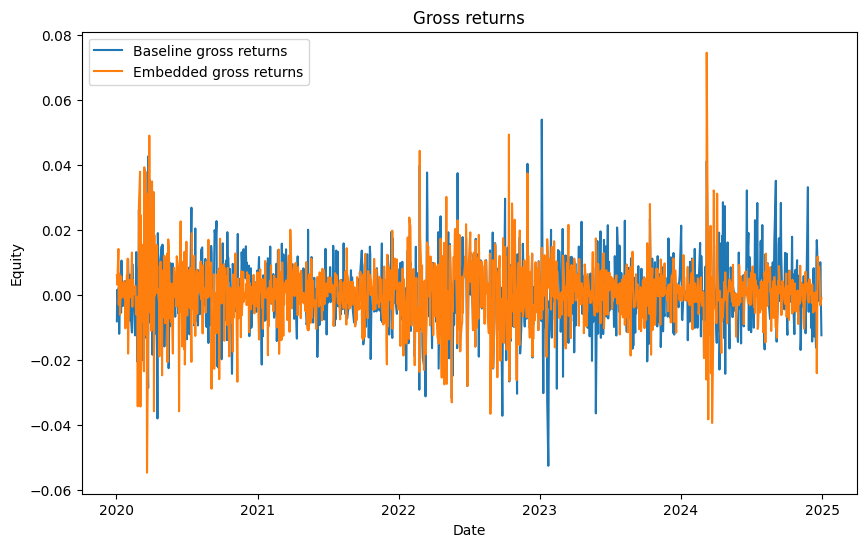

In [29]:
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["gross"], label="Baseline gross returns")
plt.plot(out_ls["embedded"]["gross"], label="Embedded gross returns")
plt.legend()
plt.title("Gross returns")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

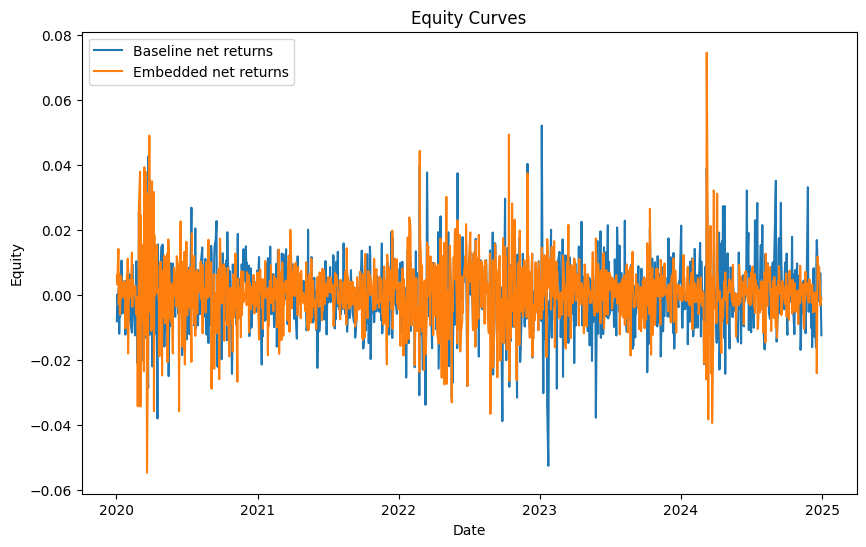

In [30]:
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["net"], label="Baseline net returns")
plt.plot(out_ls["embedded"]["net"], label="Embedded net returns")
plt.legend()
plt.title("Equity Curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

In [31]:
print("Baseline sharpe - gross returns:", perf_summary(out_ls["baseline"]["gross"])["Sharpe"])
print("Embedded sharpe - gross returns:", perf_summary(out_ls["embedded"]["gross"])["Sharpe"])

print("Baseline sharpe - net returns:", perf_summary(out_ls["baseline"]["net"])["Sharpe"])
print("Embedded sharpe - net returns:", perf_summary(out_ls["embedded"]["net"])["Sharpe"])

Baseline sharpe - gross returns: 0.6050754126493919
Embedded sharpe - gross returns: 0.7474637857688571
Baseline sharpe - net returns: -0.34359218425875265
Embedded sharpe - net returns: 0.7377327397225902


In [32]:
print("Baseline maxDD - gross returns:", perf_summary(out_ls["baseline"]["gross"])["MaxDD"])
print("Embedded maxDD - gross returns:", perf_summary(out_ls["embedded"]["gross"])["MaxDD"])

print("Baseline maxDD - net returns:", perf_summary(out_ls["baseline"]["net"])["MaxDD"])
print("Embedded maxDD - net returns:", perf_summary(out_ls["embedded"]["net"])["MaxDD"])

Baseline maxDD - gross returns: -0.31989463142414465
Embedded maxDD - gross returns: -0.14209775758068632
Baseline maxDD - net returns: -0.5395905964658803
Embedded maxDD - net returns: -0.14224955624913482


In [33]:
perf_summary(out_ls["baseline"]["gross"])

{'CAGR': 0.09014388013202534,
 'Sharpe': 0.6050754126493919,
 'MaxDD': -0.31989463142414465,
 'AvgDailyTurnover': 1.0}

In [34]:
perf_summary(out_ls["embedded"]["gross"])

{'CAGR': 0.11237471400263943,
 'Sharpe': 0.7474637857688571,
 'MaxDD': -0.14209775758068632,
 'AvgDailyTurnover': 1.0}

In [35]:
perf_summary(out_ls["baseline"]["net"])

{'CAGR': -0.06851599260931729,
 'Sharpe': -0.34359218425875265,
 'MaxDD': -0.5395905964658803,
 'AvgDailyTurnover': 1.0}

In [36]:
perf_summary(out_ls["embedded"]["net"])

{'CAGR': 0.11064827378339959,
 'Sharpe': 0.7377327397225902,
 'MaxDD': -0.14224955624913482,
 'AvgDailyTurnover': 1.0}

In [37]:

alpha_e, beta_e, t_e = alpha_beta(out_ls["embedded"]["net"], out_ls["spy_rets"])
alpha_b, beta_b, t_b = alpha_beta(out_ls["baseline"]["net"], out_ls["spy_rets"])

print("Embedded alpha/day, beta, t(alpha):", alpha_e, beta_e, t_e)
print("Baseline alpha/day, beta, t(alpha):", alpha_b, beta_b, t_b)
print("Embedded alpha/yr approx:", alpha_e * 252)


Embedded alpha/day, beta, t(alpha): 0.00023297726456087924 0.9434270533298929 1.7158539656479066
Baseline alpha/day, beta, t(alpha): -0.0002560388821635996 0.11802582915587653 -0.8702666133247459
Embedded alpha/yr approx: 0.05871027066934157


In [38]:
# Holdings on the last backtest day (includes longs + shorts)
day = out_ls["embedded"]["holdings"]["date"].max()
(out_ls["embedded"]["holdings"]
 .query("date == @day")
 .sort_values("abs_weight", ascending=False)
 .head(20))


,date,ticker,weight,abs_weight,side,pred_used,pred_raw,ret,rebalanced
37680,2024-12-30,AAPL,0.033482,0.033482,long,0.056900,0.054903,-0.000119,0
37681,2024-12-30,MSFT,0.033482,0.033482,long,0.058325,0.056494,-0.002887,0
37682,2024-12-30,AMZN,0.033482,0.033482,long,0.054857,0.053678,0.005635,0
37684,2024-12-30,GOOGL,0.033482,0.033482,long,0.053223,0.051388,0.007587,0
37685,2024-12-30,META,0.033482,0.033482,long,0.057109,0.054186,0.004229,0
37686,2024-12-30,BRK-B,0.033482,0.033482,long,0.060668,0.056847,-0.004601,0
37687,2024-12-30,JPM,0.033482,0.033482,long,0.061720,0.056564,0.002303,0
37688,2024-12-30,XOM,0.033482,0.033482,long,0.059490,0.055646,-0.005080,0
37689,2024-12-30,UNH,0.033482,0.033482,long,0.057318,0.053090,0.001855,0
37690,2024-12-30,V,0.033482,0.033482,long,0.059396,0.055128,0.002002,0


In [39]:
alpha_roll, beta_roll = rolling_alpha_beta(out_ls["embedded"]["net"], out_ls["spy_rets"], window=252)

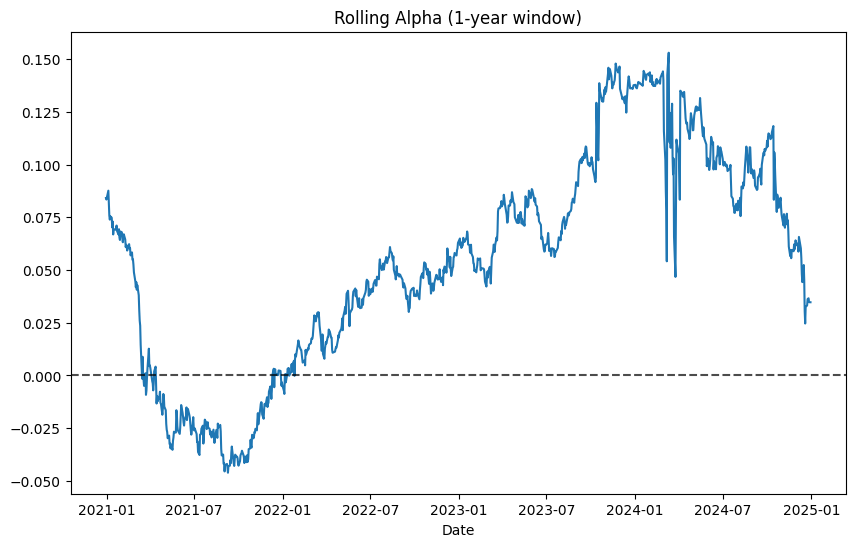

In [40]:
plt.figure(figsize=(10,6))
plt.plot(alpha_roll, label="Rolling Alpha (yr)")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Alpha (1-year window)")  
plt.xlabel("Date")
plt.show()  

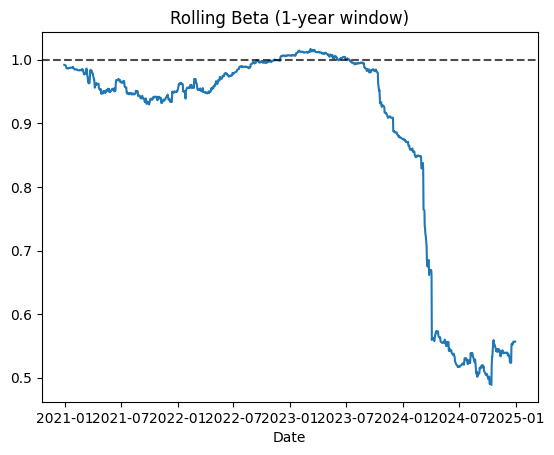

In [41]:
plt.Figure(figsize=(10,6))
plt.plot(beta_roll, label="Rolling Beta")  
plt.axhline(1, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Beta (1-year window)")
plt.xlabel("Date")
plt.show()

## Stress tests (Long-Short)

This section assumes you already ran:

```python
out_ls = run_experiment(..., weight_mode="long_short", gross_long=..., gross_short=...)
```

and uses `out_ls` directly where possible.

We run 4 tests:
1. Cost + slippage sweep (fast, uses stored gross + turnover)
2. Feature ablation (retrain; slower)
3. Placebo: shuffle Y in training (retrain; should kill edge)
4. Monte Carlo (50k bootstrap paths on embedded net returns)


In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Helpers: metrics & recompute net under alternative cost assumptions
# ----------------------------

def perf_summary_with_turnover(bt_out, which="net", freq=252):
    'Compute CAGR/Sharpe/MaxDD, plus avg turnover and final equity.'
    r = bt_out[which].dropna()
    if len(r) < 10:
        return {}
    mu = r.mean()
    sd = r.std(ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)

    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    mdd = dd.min()

    cagr = eq.iloc[-1] ** (freq / len(r)) - 1

    avg_to = float(bt_out.get("turnover", pd.Series(index=r.index, data=np.nan)).reindex(r.index).mean())
    return {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "AvgTurnover": float(avg_to) if np.isfinite(avg_to) else np.nan,
        "FinalEquity": float(eq.iloc[-1]),
        "N": int(len(r)),
    }

def recompute_net_from_gross_and_turnover(bt_out, tc_bps_per_side, slip_bps):
    'Recompute net returns and equity for new costs WITHOUT rerunning the model.'
    gross = bt_out["gross"].copy()
    turnover = bt_out["turnover"].reindex(gross.index).fillna(0.0)

    cost_rate = (tc_bps_per_side + slip_bps) / 1e4
    net = gross - cost_rate * turnover
    eq = (1 + net.fillna(0)).cumprod()

    out = dict(bt_out)  # shallow copy
    out["net_recosted"] = net
    out["equity_recosted"] = eq
    return out

# Sanity: confirm out_ls exists
assert "out_ls" in globals(), "Run your main experiment first so out_ls exists."
print("Using universe size:", len(out_ls["universe"]))
print("Feature names:", out_ls["feat_names"])


Using universe size: 30
Feature names: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']


,tc_bps_per_side,slip_bps,total_bps,baseline_sharpe,embedded_sharpe,baseline_cagr,embedded_cagr,baseline_maxdd,embedded_maxdd,baseline_final_eq,embedded_final_eq,avg_turnover_baseline,avg_turnover_embedded
0,5.0,2.0,7.0,-0.972686,0.720699,-0.215211,0.101581,-0.828699,-0.143174,2.352021e-01,1.782100,1.181467,0.002247
1,10.0,5.0,15.0,-2.031153,0.717673,-0.381889,0.101082,-0.948175,-0.143381,5.652030e-02,1.777286,1.181467,0.002247
2,20.0,10.0,30.0,-3.977659,0.711998,-0.605270,0.100148,-0.996238,-0.143770,3.881613e-03,1.768293,1.181467,0.002247
3,30.0,15.0,45.0,-5.851825,0.706323,-0.748194,0.099214,-0.999738,-0.144520,2.648730e-04,1.759347,1.181467,0.002247
4,60.0,30.0,90.0,-10.850854,0.689297,-0.935055,0.096416,-1.000000,-0.148051,8.095930e-08,1.732776,1.181467,0.002247


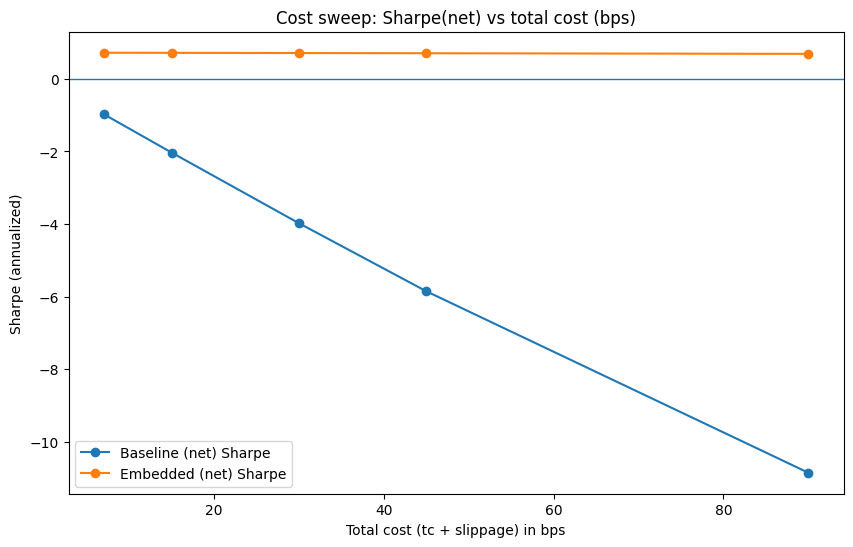

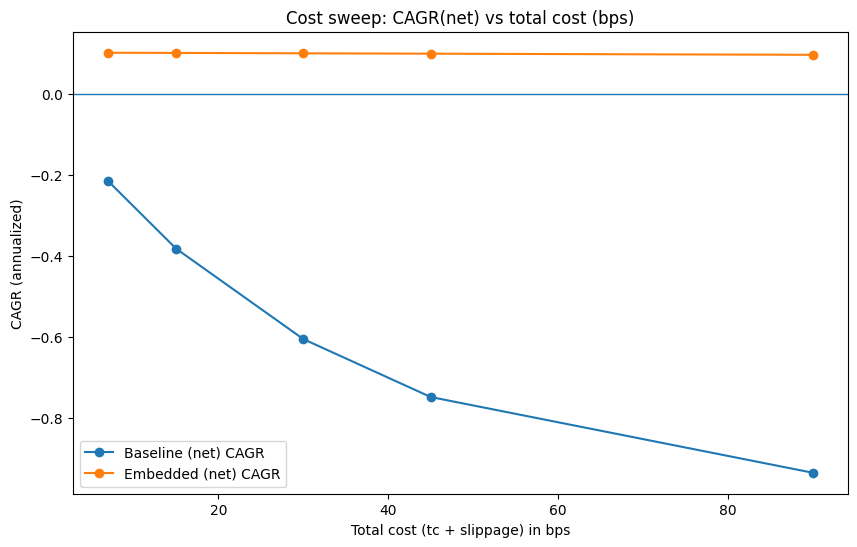

In [16]:

# ----------------------------
# 1) Cost + slippage sweep (FAST)
# ----------------------------

COST_GRID = [
    (5.0, 2.0),   # tc, slip (bps)
    (10.0, 5.0),
    (20.0, 10.0),
    (30.0, 15.0),
    (60.0, 30.0),
]

rows = []
for tc, slip in COST_GRID:
    base_rc = recompute_net_from_gross_and_turnover(out_ls["baseline"], tc, slip)
    emb_rc  = recompute_net_from_gross_and_turnover(out_ls["embedded"], tc, slip)

    s_base = perf_summary_with_turnover(base_rc, which="net_recosted")
    s_emb  = perf_summary_with_turnover(emb_rc,  which="net_recosted")

    rows.append({
        "tc_bps_per_side": tc,
        "slip_bps": slip,
        "total_bps": tc + slip,
        "baseline_sharpe": s_base.get("Sharpe", np.nan),
        "embedded_sharpe": s_emb.get("Sharpe", np.nan),
        "baseline_cagr": s_base.get("CAGR", np.nan),
        "embedded_cagr": s_emb.get("CAGR", np.nan),
        "baseline_maxdd": s_base.get("MaxDD", np.nan),
        "embedded_maxdd": s_emb.get("MaxDD", np.nan),
        "baseline_final_eq": s_base.get("FinalEquity", np.nan),
        "embedded_final_eq": s_emb.get("FinalEquity", np.nan),
        "avg_turnover_baseline": s_base.get("AvgTurnover", np.nan),
        "avg_turnover_embedded": s_emb.get("AvgTurnover", np.nan),
    })

cost_df = pd.DataFrame(rows).sort_values("total_bps")
display(cost_df)

# Plot: Sharpe vs total cost (two lines)
plt.figure(figsize=(10,6))
plt.plot(cost_df["total_bps"], cost_df["baseline_sharpe"], marker="o", label="Baseline (net) Sharpe")
plt.plot(cost_df["total_bps"], cost_df["embedded_sharpe"], marker="o", label="Embedded (net) Sharpe")
plt.axhline(0.0, linewidth=1)
plt.title("Cost sweep: Sharpe(net) vs total cost (bps)")
plt.xlabel("Total cost (tc + slippage) in bps")
plt.ylabel("Sharpe (annualized)")
plt.legend()
plt.show()

# Optional: CAGR vs cost
plt.figure(figsize=(10,6))
plt.plot(cost_df["total_bps"], cost_df["baseline_cagr"], marker="o", label="Baseline (net) CAGR")
plt.plot(cost_df["total_bps"], cost_df["embedded_cagr"], marker="o", label="Embedded (net) CAGR")
plt.axhline(0.0, linewidth=1)
plt.title("Cost sweep: CAGR(net) vs total cost (bps)")
plt.xlabel("Total cost (tc + slippage) in bps")
plt.ylabel("CAGR (annualized)")
plt.legend()
plt.show()


Epoch 01 | train pnl -0.000415 | train mse 0.003423 | val pnl +0.000121 | val mse 0.001263
Epoch 02 | train pnl +0.000185 | train mse 0.001035 | val pnl -0.000126 | val mse 0.000280
Epoch 03 | train pnl +0.000223 | train mse 0.000860 | val pnl +0.000121 | val mse 0.001436
Epoch 01 | train pnl +0.000011 | train mse 0.003888 | val pnl +0.000121 | val mse 0.007705
Epoch 02 | train pnl +0.000086 | train mse 0.001367 | val pnl -0.000121 | val mse 0.002490
Epoch 03 | train pnl +0.000112 | train mse 0.001136 | val pnl -0.000121 | val mse 0.000663
Epoch 01 | train pnl -0.000366 | train mse 0.004144 | val pnl +0.000383 | val mse 0.000276
Epoch 02 | train pnl -0.000013 | train mse 0.001283 | val pnl -0.000121 | val mse 0.000378
Epoch 03 | train pnl +0.000124 | train mse 0.000997 | val pnl +0.000121 | val mse 0.000960
Epoch 01 | train pnl +0.000175 | train mse 0.004390 | val pnl +0.000840 | val mse 0.000833
Epoch 02 | train pnl +0.000054 | train mse 0.001724 | val pnl -0.000101 | val mse 0.000260

,dropped_feature,CAGR,Sharpe,MaxDD,AvgTurnover,FinalEquity,N
8,volz20,0.102803,0.727895,-0.142712,0.000655,1.793933,1505
6,prc_ma20,0.102533,0.726115,-0.143165,0.000008,1.791315,1505
4,rev5,0.102523,0.726034,-0.143165,0.000000,1.791215,1505
5,vol20,0.102520,0.726020,-0.143165,0.000014,1.791189,1505
0,(none),0.102439,0.725574,-0.143165,0.000063,1.790399,1505
9,rsi14,0.102428,0.725462,-0.143133,0.000340,1.790292,1505
7,prc_ma60,0.102393,0.725275,-0.143233,0.000134,1.789961,1505
1,mom20,0.100930,0.716518,-0.143287,0.001889,1.775818,1505
2,mom60,-0.164669,-0.954910,-0.685963,0.212169,0.341447,1505
3,mom252,-0.215926,-1.050813,-0.803395,0.790332,0.233925,1505


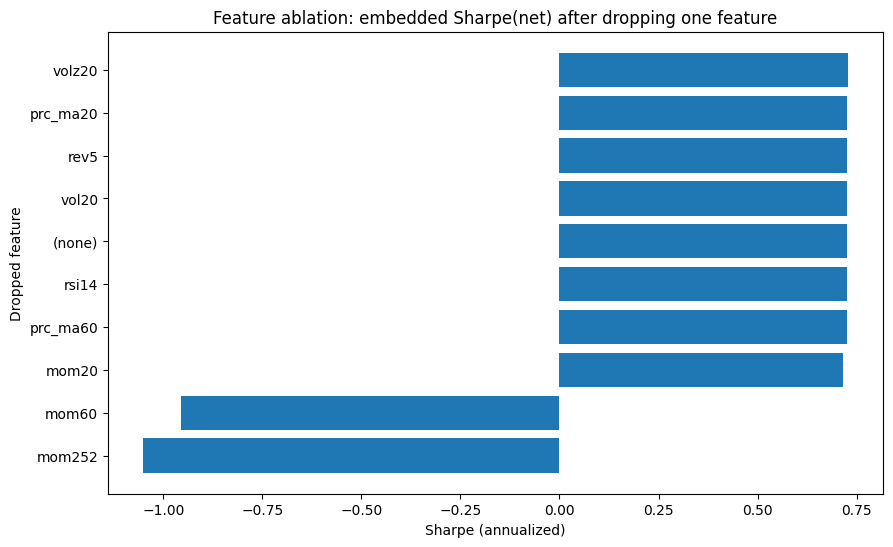

In [17]:

# ----------------------------
# 2) Feature ablation (RETRAIN; SLOWER)
# ----------------------------
# Idea: remove one feature at a time, retrain embedded model, test on the same splits.

ABL_EPOCHS = 3  # lower this to go faster

ABL_TICKERS = out_ls["universe"]
ABL_TOP_N = len(ABL_TICKERS)

def run_embedded_only_with_custom_feats(
    feats_override, y_override, *,
    tickers, seq_len=20,
    train_end="2017-12-31", val_end="2019-12-31",
    gamma=0.0, max_w=0.02,
    tc_bps=10.0, slip_bps=5.0,
    epochs=3, lr=1e-3, lam_embedded=0.8,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
):
    batches_all, feat_names = build_day_batches(feats_override, y_override, tickers=tickers, seq_len=seq_len)

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    n_features = len(feat_names)

    model_emb = train_model(
        batches_train, batches_val, n_features,
        lam=lam_embedded, k_turn=0.05, k_conc=0.05,
        gamma=gamma, max_w=max_w,
        lr=lr, epochs=epochs,
        weight_mode=weight_mode, gross_long=gross_long, gross_short=gross_short,
    )

    bt_emb = backtest_batches(
        model_emb, batches_test,
        tc_bps_per_side=tc_bps, slip_bps=slip_bps,
        gamma=gamma, max_w=max_w,
        weight_mode=weight_mode, gross_long=gross_long, gross_short=gross_short
    )
    return bt_emb, feat_names

# Re-download data (yfinance variability warning). If you want perfect reproducibility, cache data locally.
data = download_ohlcv(list(dict.fromkeys(ABL_TICKERS + ["SPY"])), start="2010-01-01", end=None, auto_adjust=False)
feats_full, y_full = make_features(data)

feat_list = list(feats_full.keys())

results = []

# Full embedded model first
bt_full, _ = run_embedded_only_with_custom_feats(
    feats_full, y_full,
    tickers=ABL_TICKERS,
    epochs=ABL_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)
s_full = perf_summary_with_turnover(bt_full, which="net")
results.append({"dropped_feature": "(none)", **s_full})

# Drop one at a time
for drop in feat_list:
    feats_abl = {k:v for k,v in feats_full.items() if k != drop}
    bt_abl, _ = run_embedded_only_with_custom_feats(
        feats_abl, y_full,
        tickers=ABL_TICKERS,
        epochs=ABL_EPOCHS,
        weight_mode="long_short", gross_long=1.0, gross_short=1.0
    )
    s = perf_summary_with_turnover(bt_abl, which="net")
    results.append({"dropped_feature": drop, **s})

abl_df = pd.DataFrame(results).sort_values("Sharpe", ascending=False)
display(abl_df)

# Plot: Sharpe by ablation
plt.figure(figsize=(10,6))
tmp = abl_df.sort_values("Sharpe")
plt.barh(tmp["dropped_feature"], tmp["Sharpe"])
plt.title("Feature ablation: embedded Sharpe(net) after dropping one feature")
plt.xlabel("Sharpe (annualized)")
plt.ylabel("Dropped feature")
plt.show()


Training placebo baseline (MSE only) on shuffled labels...
Epoch 01 | train pnl +0.000024 | train mse 0.000700 | val pnl +0.000167 | val mse 0.000338
Epoch 02 | train pnl -0.000104 | train mse 0.000349 | val pnl +0.000186 | val mse 0.000613
Epoch 03 | train pnl +0.000169 | train mse 0.000305 | val pnl +0.000127 | val mse 0.000234

Training placebo embedded on shuffled labels...
Epoch 01 | train pnl +0.000081 | train mse 0.003096 | val pnl -0.000345 | val mse 0.000241
Epoch 02 | train pnl +0.000055 | train mse 0.001330 | val pnl +0.000121 | val mse 0.001865
Epoch 03 | train pnl +0.000218 | train mse 0.000816 | val pnl -0.000136 | val mse 0.000357

Placebo results (should be near 0 or negative after costs):
Baseline placebo: {'CAGR': -0.04207611142682055, 'Sharpe': -0.19247668858136566, 'MaxDD': -0.397930740133983, 'AvgTurnover': 0.22429683596593172, 'FinalEquity': 0.7741069010051052, 'N': 1501}
Embedded placebo: {'CAGR': 0.10101506234956403, 'Sharpe': 0.7162223514713034, 'MaxDD': -0.143

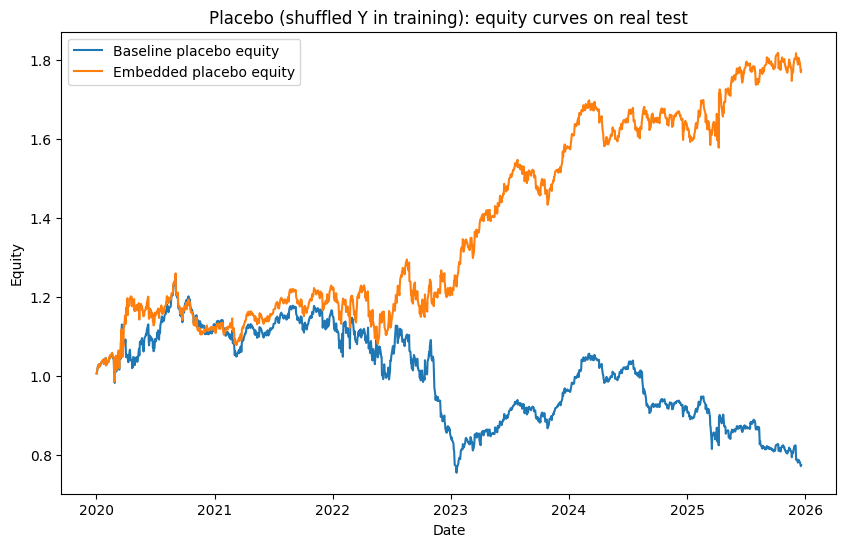

In [18]:

# ----------------------------
# 3) Placebo: shuffle Y in TRAINING (RETRAIN; should kill edge)
# ----------------------------
# Shuffle labels within each day across tickers for train+val only, then evaluate on real test.

PLACEBO_EPOCHS = 3
PLACEBO_TICKERS = out_ls["universe"]

data_p = download_ohlcv(list(dict.fromkeys(PLACEBO_TICKERS + ["SPY"])), start="2010-01-01", end=None, auto_adjust=False)
feats_p, y_p = make_features(data_p)

batches_all, feat_names = build_day_batches(feats_p, y_p, tickers=PLACEBO_TICKERS, seq_len=20)

train_end_dt = pd.to_datetime("2017-12-31")
val_end_dt = pd.to_datetime("2019-12-31")
batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

def shuffle_batch_Y(batches, seed):
    rng = np.random.default_rng(seed)
    out = []
    for (dt, X, Y) in batches:
        Y2 = Y.copy()
        rng.shuffle(Y2)  # permutes across tickers within the day
        out.append((dt, X, Y2))
    return out

batches_train_shuf = shuffle_batch_Y(batches_train, seed=1)
batches_val_shuf   = shuffle_batch_Y(batches_val,   seed=2)

n_features = len(feat_names)

print("Training placebo baseline (MSE only) on shuffled labels...")
model_base_p = train_model(
    batches_train_shuf, batches_val_shuf, n_features,
    lam=0.0, k_turn=0.0, k_conc=0.0,
    gamma=0.0, max_w=0.02,
    lr=1e-3, epochs=PLACEBO_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

print("\nTraining placebo embedded on shuffled labels...")
model_emb_p = train_model(
    batches_train_shuf, batches_val_shuf, n_features,
    lam=0.8, k_turn=0.05, k_conc=0.05,
    gamma=0.0, max_w=0.02,
    lr=1e-3, epochs=PLACEBO_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

bt_base_p = backtest_batches(
    model_base_p, batches_test,
    tc_bps_per_side=10.0, slip_bps=5.0,
    gamma=0.0, max_w=0.02,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)
bt_emb_p = backtest_batches(
    model_emb_p, batches_test,
    tc_bps_per_side=10.0, slip_bps=5.0,
    gamma=0.0, max_w=0.02,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

print("\nPlacebo results (should be near 0 or negative after costs):")
print("Baseline placebo:", perf_summary_with_turnover(bt_base_p, "net"))
print("Embedded placebo:", perf_summary_with_turnover(bt_emb_p, "net"))

# Plot: placebo equity curves
plt.figure(figsize=(10,6))
plt.plot(bt_base_p["equity"], label="Baseline placebo equity")
plt.plot(bt_emb_p["equity"], label="Embedded placebo equity")
plt.title("Placebo (shuffled Y in training): equity curves on real test")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.show()


,value
CAGR_p01,-0.046224
CAGR_p05,-0.005551
CAGR_p25,0.055491
CAGR_p50,0.099690
CAGR_p75,0.145844
CAGR_p95,0.217133
CAGR_p99,0.268854
CAGR_mean,0.101876
CAGR_std,0.067587
Sharpe_p01,-0.245599


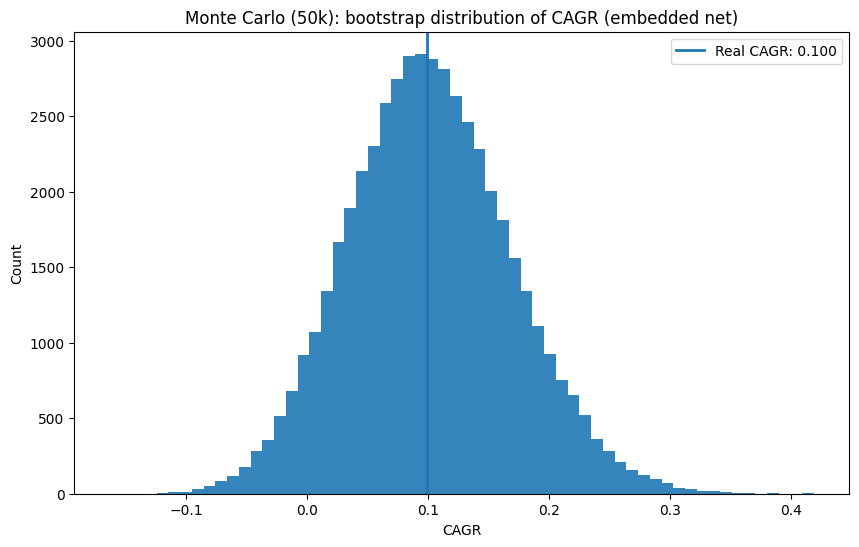

In [19]:

# ----------------------------
# 4) Monte Carlo bootstrap (50k sims) on embedded NET returns
# ----------------------------
# Resampling Monte Carlo on realized daily returns.
# Note: IID bootstrap is fast but ignores volatility clustering; block bootstrap is more realistic.

MC_SIMS = 50_000
CHUNK = 1000  # adjust for memory/speed

r = out_ls["embedded"]["net"].dropna().values.astype(np.float64)
T = len(r)
freq = 252

if T < 50:
    raise RuntimeError("Not enough returns for Monte Carlo.")

def mc_metrics_chunk(r, n_sims, rng):
    idx = rng.integers(0, len(r), size=(n_sims, len(r)))
    R = r[idx]  # [n_sims, T]

    mu = R.mean(axis=1)
    sd = R.std(axis=1, ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)

    EQ = np.cumprod(1.0 + R, axis=1)
    final_eq = EQ[:, -1]
    cagr = final_eq ** (freq / T) - 1.0

    peak = np.maximum.accumulate(EQ, axis=1)
    dd = EQ / (peak + 1e-12) - 1.0
    mdd = dd.min(axis=1)

    return sharpe, cagr, mdd

rng = np.random.default_rng(12345)
sharpes = np.empty(MC_SIMS, dtype=np.float64)
cagrs   = np.empty(MC_SIMS, dtype=np.float64)
mdds    = np.empty(MC_SIMS, dtype=np.float64)

pos = 0
while pos < MC_SIMS:
    n = min(CHUNK, MC_SIMS - pos)
    s, c, m = mc_metrics_chunk(r, n, rng)
    sharpes[pos:pos+n] = s
    cagrs[pos:pos+n]   = c
    mdds[pos:pos+n]    = m
    pos += n

def summarize_mc(arr, name):
    p = np.percentile(arr, [1, 5, 25, 50, 75, 95, 99])
    return {
        f"{name}_p01": p[0],
        f"{name}_p05": p[1],
        f"{name}_p25": p[2],
        f"{name}_p50": p[3],
        f"{name}_p75": p[4],
        f"{name}_p95": p[5],
        f"{name}_p99": p[6],
        f"{name}_mean": float(arr.mean()),
        f"{name}_std": float(arr.std(ddof=0)),
    }

mc_summary = {}
mc_summary.update(summarize_mc(cagrs, "CAGR"))
mc_summary.update(summarize_mc(sharpes, "Sharpe"))
mc_summary.update(summarize_mc(mdds, "MaxDD"))

mc_summary["P(CAGR<0)"] = float((cagrs < 0).mean())
mc_summary["P(Sharpe<0)"] = float((sharpes < 0).mean())
mc_summary["P(MaxDD<-0.3)"] = float((mdds < -0.3).mean())

display(pd.DataFrame([mc_summary]).T.rename(columns={0:"value"}))

# Plot: histogram of CAGR
plt.figure(figsize=(10,6))
plt.hist(cagrs, bins=60, alpha=0.9)
real_cagr = perf_summary_with_turnover(out_ls["embedded"], "net").get("CAGR", np.nan)
plt.axvline(real_cagr, linewidth=2, label=f"Real CAGR: {real_cagr:.3f}")
plt.title("Monte Carlo (50k): bootstrap distribution of CAGR (embedded net)")
plt.xlabel("CAGR")
plt.ylabel("Count")
plt.legend()
plt.show()


## MonteVarlo simulation

In [15]:

# ============================================================
# (NEW) Freeze model + Market Monte Carlo (simulate the market)
# Uses the FINAL trained model (no retraining)
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def save_frozen_model(path="frozen_embedded_longshort.pt", which="embedded"):
    """
    Save the final trained model from the most recent run_experiment().
    This respects your workflow: run_experiment(...) -> out_ls exists,
    and we also expose LAST_MODEL_EMB/LAST_MODEL_BASE from inside run_experiment.
    """
    if which not in ("embedded","baseline"):
        raise ValueError("which must be 'embedded' or 'baseline'")

    model = LAST_MODEL_EMB if which=="embedded" else LAST_MODEL_BASE
    if model is None:
        raise RuntimeError("No trained model found. Run run_experiment(...) first.")

    meta = dict(
        which=which,
        feat_names=LAST_FEAT_NAMES,
        n_features=len(LAST_FEAT_NAMES),
        hidden=64,  # must match train_model() architecture
        seq_len=LAST_RUN_CFG["seq_len"],
        gamma=LAST_RUN_CFG["gamma"],
        max_w=LAST_RUN_CFG["max_w"],
        weight_mode=LAST_RUN_CFG["weight_mode"],
        gross_long=LAST_RUN_CFG["gross_long"],
        gross_short=LAST_RUN_CFG["gross_short"],
    )

    torch.save({"state_dict": model.state_dict(), "meta": meta}, path)
    print(f"Saved frozen {which} model to: {path}")
    return path

def load_frozen_model(path="frozen_embedded_longshort.pt", device=DEVICE):
    payload = torch.load(path, map_location=device)
    meta = payload["meta"]
    model = LSTMAlpha(n_features=meta["n_features"], hidden=meta["hidden"]).to(device)
    model.load_state_dict(payload["state_dict"])
    model.eval()
    print(f"Loaded frozen model from: {path}")
    return model, meta


# ----------------------------
# Market simulator (factor model + bull/bear regimes)
# ----------------------------
def calibrate_factor_model(data, tickers, k=3):
    """
    Calibrate a simple k-factor model from historical close-to-close log returns.
    This gives realistic cross-sectional correlation (important for long/short).
    """
    close = data["Close"][tickers].dropna()
    rets = np.log(close).diff().dropna()  # log returns, shape [T, N]
    R = rets.values
    mu = R.mean(axis=0)
    Rc = R - mu

    cov = np.cov(Rc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

    W = eigvecs[:, :k]
    S = np.diag(np.sqrt(np.maximum(eigvals[:k], 1e-12)))
    betas = W @ S  # [N, k]

    B = betas
    BtB_inv = np.linalg.pinv(B.T @ B)
    F = (BtB_inv @ B.T @ Rc.T).T  # factor returns [T, k]

    factor_mu = F.mean(axis=0)
    factor_cov = np.cov(F, rowvar=False)

    R_hat = F @ B.T
    E = Rc - R_hat
    resid_std = E.std(axis=0, ddof=0)

    calib = dict(
        tickers=tickers,
        start_prices=close.iloc[0].values,
        dates=close.index,
        betas=betas,
        factor_mu=factor_mu,
        factor_cov=factor_cov,
        resid_std=resid_std,
    )
    return calib

def simulate_ohlcv_factor_regime(
    calib,
    dates,
    seed=0,
    bull_mu_shift=0.0003,
    bear_mu_shift=-0.0008,
    bull_vol_mult=1.0,
    bear_vol_mult=1.6,
    p_switch=0.01,
    gap_frac=0.25,
    vol_logn_mu=12.0,
    vol_logn_sigma=0.7,
):
    """
    Produce a dict with keys Open, Close, Volume, High, Low matching your pipeline.
    """
    rng = np.random.default_rng(seed)
    tickers = calib["tickers"]
    n = len(tickers)
    T = len(dates)

    B = calib["betas"]
    f_mu = calib["factor_mu"]
    f_cov = calib["factor_cov"]
    eps_std = calib["resid_std"]
    Lf = np.linalg.cholesky(f_cov + 1e-12*np.eye(f_cov.shape[0]))

    reg = np.zeros(T, dtype=int)
    for t in range(1, T):
        if rng.random() < p_switch:
            reg[t] = 1 - reg[t-1]
        else:
            reg[t] = reg[t-1]

    open_px = np.zeros((T, n))
    close_px = np.zeros((T, n))
    volu = np.zeros((T, n))

    close_prev = calib["start_prices"].copy()

    for t in range(T):
        is_bear = (reg[t] == 1)
        mu_shift = bear_mu_shift if is_bear else bull_mu_shift
        vol_mult = bear_vol_mult if is_bear else bull_vol_mult

        zf = rng.standard_normal(Lf.shape[0])
        f_t = f_mu + (Lf @ zf) * vol_mult

        ze = rng.standard_normal(n)
        eps_t = ze * eps_std * vol_mult

        r_total = (B @ f_t) + eps_t + mu_shift  # log return close-to-close

        # Split into overnight gap + intraday move
        gap = rng.standard_normal(n) * (np.std(r_total) + 1e-6) * gap_frac
        intraday = r_total - gap

        open_t = close_prev * np.exp(gap)
        close_t = open_t * np.exp(intraday)

        # volume: lognormal base * (1 + activity)
        baseV = rng.lognormal(mean=vol_logn_mu, sigma=vol_logn_sigma, size=n)
        vol_t = baseV * (1.0 + 10.0*np.abs(intraday))

        open_px[t] = open_t
        close_px[t] = close_t
        volu[t] = vol_t
        close_prev = close_t

    df_open = pd.DataFrame(open_px, index=dates, columns=tickers)
    df_close = pd.DataFrame(close_px, index=dates, columns=tickers)
    df_vol = pd.DataFrame(volu, index=dates, columns=tickers)

    df_high = pd.DataFrame(np.maximum(df_open, df_close), index=dates, columns=tickers)
    df_low  = pd.DataFrame(np.minimum(df_open, df_close), index=dates, columns=tickers)

    return {"Open": df_open, "Close": df_close, "Volume": df_vol, "High": df_high, "Low": df_low, "regime": reg}


# ----------------------------
# Run frozen model on a simulated market
# ----------------------------
def backtest_frozen_on_simulated_market(
    model_frozen,
    meta,
    data_sim,
    tickers,
    tc_bps=10.0,
    slip_bps=5.0,
):
    feats, y = make_features(data_sim)
    batches_all, feat_names = build_day_batches(feats, y, tickers=tickers, seq_len=meta["seq_len"])

    bt = backtest_batches(
        model_frozen,
        batches_all,
        tc_bps_per_side=tc_bps,
        slip_bps=slip_bps,
        gamma=meta["gamma"],
        max_w=meta["max_w"],
        weight_mode=meta["weight_mode"],
        gross_long=meta["gross_long"],
        gross_short=meta["gross_short"],
    )
    return bt


def market_monte_carlo(
    model_frozen,
    meta,
    calib,
    n_sims=200,
    seed0=123,
    tc_bps=10.0,
    slip_bps=5.0,
    sim_params=None,
):
    """
    Monte Carlo market simulation with the frozen final model.
    Returns:
      eq_df: [date x sim] equity paths
      met_df: per-sim performance summary table
    """
    if sim_params is None:
        sim_params = {}

    dates = calib["dates"]
    tickers = calib["tickers"]

    equities = []
    rows = []

    for s in range(n_sims):
        data_sim = simulate_ohlcv_factor_regime(
            calib,
            dates=dates,
            seed=seed0 + s,
            **sim_params
        )
        bt = backtest_frozen_on_simulated_market(
            model_frozen, meta,
            data_sim=data_sim,
            tickers=tickers,
            tc_bps=tc_bps,
            slip_bps=slip_bps,
        )

        eq = bt["equity"].copy()
        equities.append(eq.rename(f"sim_{s}"))

        summ = perf_summary(bt["net"])
        summ["FinalEquity"] = float(eq.iloc[-1])
        rows.append(summ)

    eq_df = pd.concat(equities, axis=1)
    met_df = pd.DataFrame(rows)
    return eq_df, met_df


def plot_fanchart_and_variance(eq_df, title="Monte Carlo Equity Fan Chart"):
    eq = eq_df.ffill().dropna(how="all")
    mean = eq.mean(axis=1)
    p05 = eq.quantile(0.05, axis=1)
    p25 = eq.quantile(0.25, axis=1)
    p75 = eq.quantile(0.75, axis=1)
    p95 = eq.quantile(0.95, axis=1)
    var = eq.var(axis=1)

    plt.figure(figsize=(10,6))
    plt.plot(mean, label="Mean equity")
    plt.plot(p05, linestyle="--", alpha=0.7, label="p05")
    plt.plot(p95, linestyle="--", alpha=0.7, label="p95")
    plt.plot(p25, linestyle=":", alpha=0.7, label="p25")
    plt.plot(p75, linestyle=":", alpha=0.7, label="p75")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,6))
    plt.plot(var)
    plt.title("Variance of equity across simulations (robustness over time)")
    plt.xlabel("Date")
    plt.ylabel("Var(Equity)")
    plt.show()


def plot_metric_histograms(met_df, real_metrics=None):
    for col in ["CAGR", "Sharpe", "MaxDD", "FinalEquity"]:
        if col not in met_df.columns:
            continue
        plt.figure(figsize=(10,6))
        plt.hist(met_df[col].dropna().values, bins=50)
        if real_metrics is not None and col in real_metrics:
            plt.axvline(real_metrics[col])
        plt.title(f"Distribution of {col} across market simulations")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    if "CAGR" in met_df.columns:
        print("P(CAGR < 0):", float((met_df["CAGR"] < 0).mean()))
    if "Sharpe" in met_df.columns:
        print("P(Sharpe < 0):", float((met_df["Sharpe"] < 0).mean()))
    if "MaxDD" in met_df.columns:
        print("P(MaxDD < -0.30):", float((met_df["MaxDD"] < -0.30).mean()))


Saved frozen embedded model to: frozen_embedded_longshort.pt
Loaded frozen model from: frozen_embedded_longshort.pt


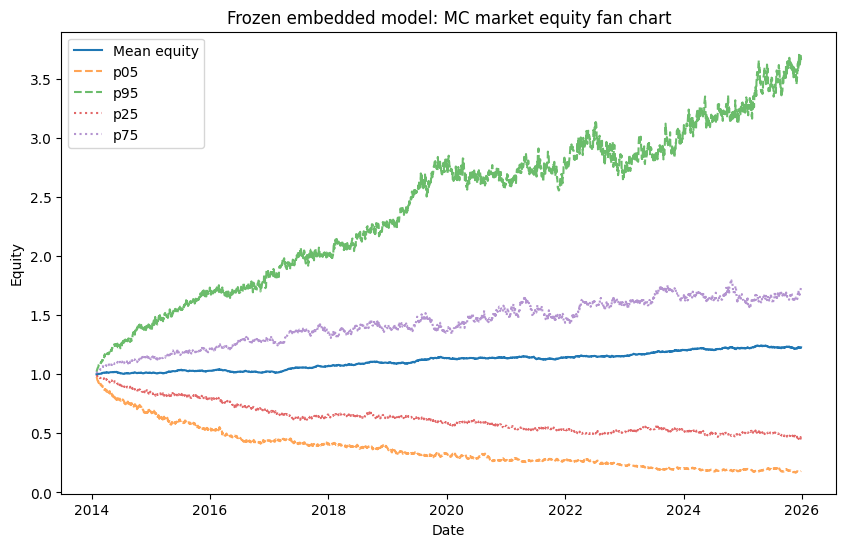

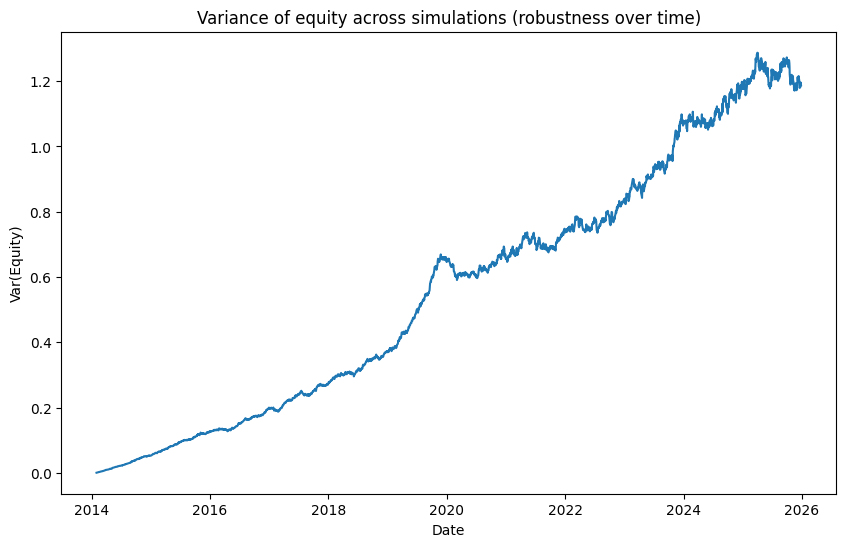

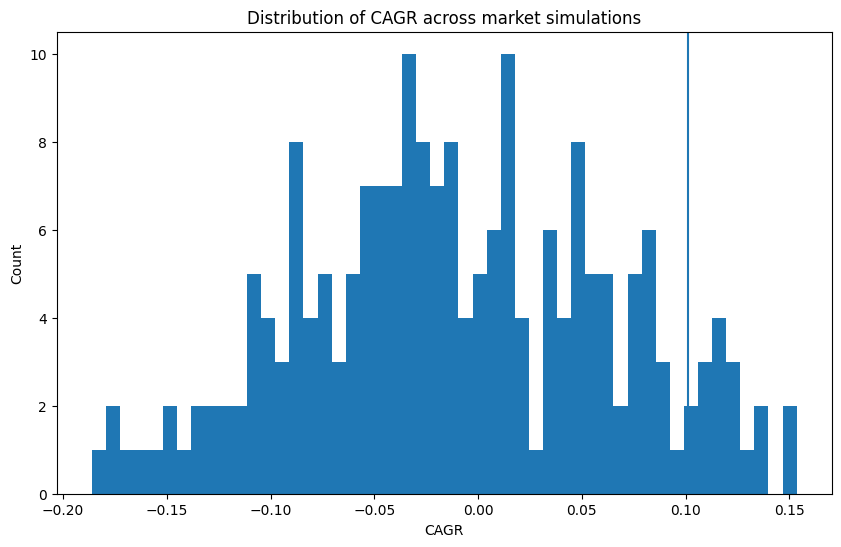

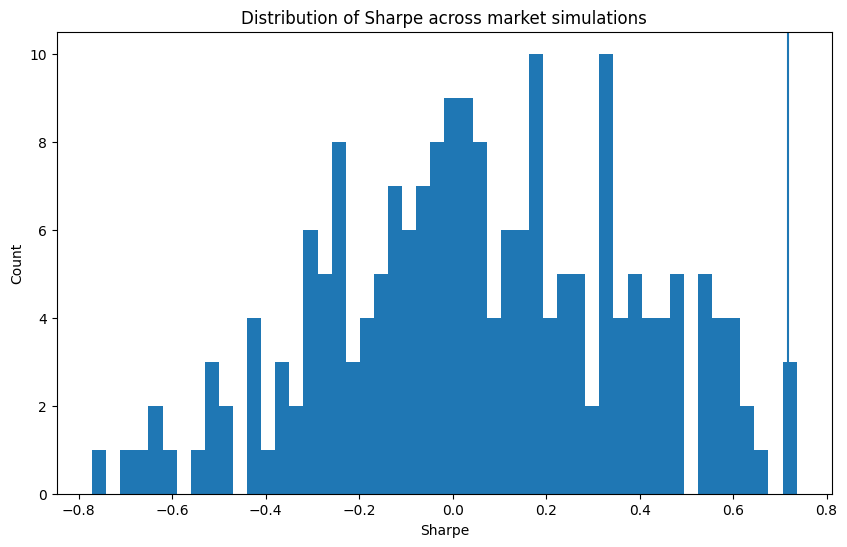

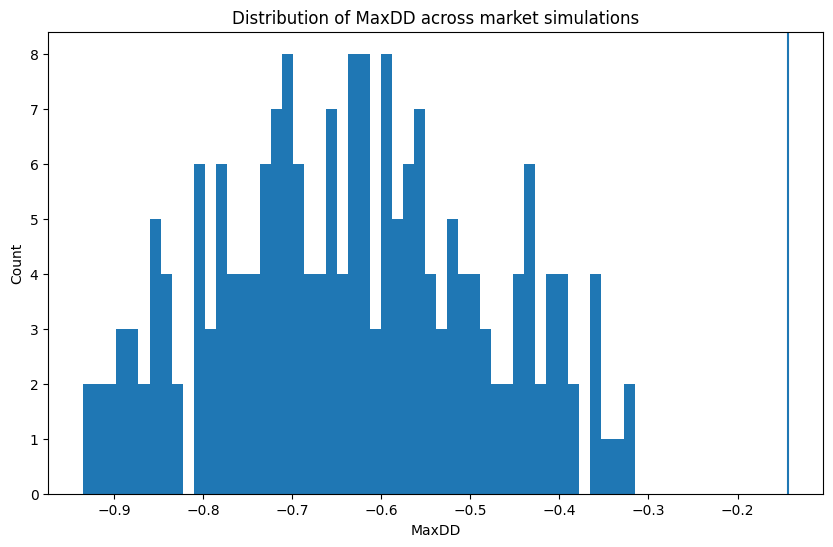

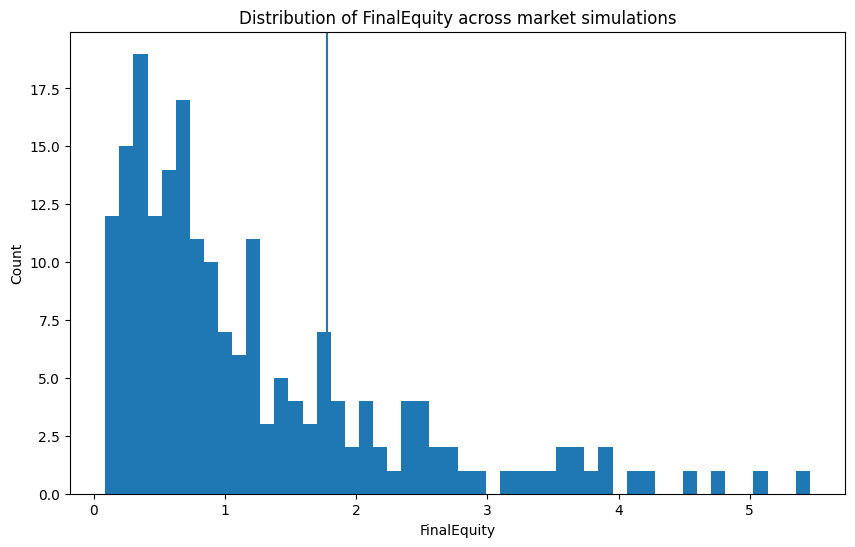

P(CAGR < 0): 0.575
P(Sharpe < 0): 0.43
P(MaxDD < -0.30): 1.0
Real (historical) metrics: {'CAGR': 0.10108238402341874, 'Sharpe': 0.7176726144467378, 'MaxDD': -0.14338132655938263, 'AvgDailyTurnover': 1.0, 'FinalEquity': 1.7772856139402502}
MC metrics summary (mean/median):


,CAGR,Sharpe,MaxDD,AvgDailyTurnover,FinalEquity
count,200.000000,200.000000,200.000000,200.0,200.000000
mean,-0.011388,0.061449,-0.635522,1.0,1.227895
std,0.074719,0.321026,0.149621,0.0,1.089712
min,-0.185997,-0.771031,-0.934805,1.0,0.086656
1%,-0.174114,-0.661144,-0.922030,1.0,0.102945
5%,-0.133992,-0.490930,-0.878215,1.0,0.180922
25%,-0.062633,-0.152296,-0.740026,1.0,0.463609
50%,-0.015517,0.051954,-0.635043,1.0,0.830631
75%,0.047652,0.316002,-0.528181,1.0,1.738919
95%,0.115373,0.581003,-0.390298,1.0,3.660891


In [16]:

# ============================================================
# (NEW) How to run market Monte Carlo with your final model
# ============================================================

from IPython.display import display

# 1) Save the final trained embedded model from your last run_experiment()
frozen_path = save_frozen_model(path="frozen_embedded_longshort.pt", which="embedded")

# 2) Load it (to prove we are using the frozen final model)
model_frozen, meta_frozen = load_frozen_model(frozen_path, device=DEVICE)

# 3) Calibrate the market simulator from historical data for the SAME universe
tickers_sim = out_ls["universe"]
data_hist = download_ohlcv(tickers_sim, start="2010-01-01", end=None, auto_adjust=False)
calib = calibrate_factor_model(data_hist, tickers=tickers_sim, k=3)

# 4) Run market Monte Carlo (start with 200 sims; increase if you want)
#    Note: true "50k market sims" is usually too heavy; if you insist, raise n_sims carefully.
eq_mc, met_mc = market_monte_carlo(
    model_frozen,
    meta_frozen,
    calib,
    n_sims=200,
    seed0=123,
    tc_bps=out_ls.get("tc_bps", 10.0) if isinstance(out_ls, dict) else 10.0,
    slip_bps=out_ls.get("slip_bps", 5.0) if isinstance(out_ls, dict) else 5.0,
    sim_params=dict(
        # You can stress the market here:
        # bear_mu_shift=-0.0012,
        # p_switch=0.02,
        # bear_vol_mult=2.0,
    ),
)

# 5) Plot robustness over time: fan chart + variance curve
plot_fanchart_and_variance(eq_mc, title="Frozen embedded model: MC market equity fan chart")

# 6) Compare distributions to the REAL backtest metrics from your historical test set
real = perf_summary(out_ls["embedded"]["net"])
real["FinalEquity"] = float(out_ls["embedded"]["equity"].iloc[-1])

plot_metric_histograms(met_mc, real_metrics=real)

print("Real (historical) metrics:", real)
print("MC metrics summary (mean/median):")
display(met_mc.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))
